In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler,RobustScaler,LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import Lasso
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
import statsmodels.api as sm

In [2]:
df=pd.read_csv("C:/Users/acer/Desktop/machine_learning project/day.csv")

In [3]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [4]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    str    
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.5 KB


<Axes: xlabel='cnt', ylabel='Count'>

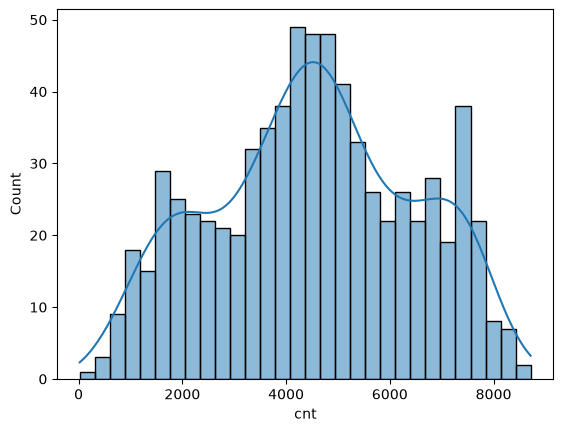

In [6]:
sns.histplot(x='cnt',data=df,bins=30,kde=True)

In [7]:
df.drop(columns=['instant', 'dteday', 'casual', 'registered'], inplace=True)

In [8]:
df

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,1600
...,...,...,...,...,...,...,...,...,...,...,...,...
725,1,1,12,0,4,1,2,10.420847,11.33210,65.2917,23.458911,2114
726,1,1,12,0,5,1,2,10.386653,12.75230,59.0000,10.416557,3095
727,1,1,12,0,6,0,2,10.386653,12.12000,75.2917,8.333661,1341
728,1,1,12,0,0,0,1,10.489153,11.58500,48.3333,23.500518,1796


In [9]:
df["season"]=df["season"].map({1:"spring",2:"summer",3:"fall",4:"winter"})

In [10]:
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,spring,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,985
1,spring,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,801
2,spring,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,1349
3,spring,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,1562
4,spring,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,1600


In [11]:
df["mnth"]=df["mnth"].map({1:"jan",2:"feb",3:"mar",4:"apr",5:"may",6:"jun",7:"jul",8:"aug",9:"sep",10:"oct",11:"nov",12:"dec"})

In [12]:
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,spring,0,jan,0,6,0,2,14.110847,18.18125,80.5833,10.749882,985
1,spring,0,jan,0,0,0,2,14.902598,17.68695,69.6087,16.652113,801
2,spring,0,jan,0,1,1,1,8.050924,9.47025,43.7273,16.636703,1349
3,spring,0,jan,0,2,1,1,8.200000,10.60610,59.0435,10.739832,1562
4,spring,0,jan,0,3,1,1,9.305237,11.46350,43.6957,12.522300,1600


In [13]:
df["weekday"]=df["weekday"].map({0:"sun",1:"mon",2:"tue",3:"wed",4:"thu",5:"fri",6:"sat"})
df["weathersit"]=df["weathersit"].map({1:"clear",2:"misty",3:"light snow/rain",4:"heavy rain/snow"})

In [14]:
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,spring,0,jan,0,sat,0,misty,14.110847,18.18125,80.5833,10.749882,985
1,spring,0,jan,0,sun,0,misty,14.902598,17.68695,69.6087,16.652113,801
2,spring,0,jan,0,mon,1,clear,8.050924,9.47025,43.7273,16.636703,1349
3,spring,0,jan,0,tue,1,clear,8.200000,10.60610,59.0435,10.739832,1562
4,spring,0,jan,0,wed,1,clear,9.305237,11.46350,43.6957,12.522300,1600


Numerical

temp
atemp
hum
windspeed

Categorical

season
mnth
weekday
weathersit

Binary

yr
holiday
workingday

Target

cnt

In [15]:
print(df.isnull().sum())
print(df.duplicated().sum())

season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64
0


In [16]:
df = pd.get_dummies(
    df,
    columns=["season", "mnth", "weekday", "weathersit"],
    drop_first=True,
    dtype=int
)

In [17]:
df

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_spring,season_summer,...,mnth_oct,mnth_sep,weekday_mon,weekday_sat,weekday_sun,weekday_thu,weekday_tue,weekday_wed,weathersit_light snow/rain,weathersit_misty
0,0,0,0,14.110847,18.18125,80.5833,10.749882,985,1,0,...,0,0,0,1,0,0,0,0,0,1
1,0,0,0,14.902598,17.68695,69.6087,16.652113,801,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,0,1,8.050924,9.47025,43.7273,16.636703,1349,1,0,...,0,0,1,0,0,0,0,0,0,0
3,0,0,1,8.200000,10.60610,59.0435,10.739832,1562,1,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,1,9.305237,11.46350,43.6957,12.522300,1600,1,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,1,0,1,10.420847,11.33210,65.2917,23.458911,2114,1,0,...,0,0,0,0,0,1,0,0,0,1
726,1,0,1,10.386653,12.75230,59.0000,10.416557,3095,1,0,...,0,0,0,0,0,0,0,0,0,1
727,1,0,0,10.386653,12.12000,75.2917,8.333661,1341,1,0,...,0,0,0,1,0,0,0,0,0,1
728,1,0,0,10.489153,11.58500,48.3333,23.500518,1796,1,0,...,0,0,0,0,1,0,0,0,0,0


In [18]:
X = df.drop("cnt", axis=1)
y = df["cnt"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

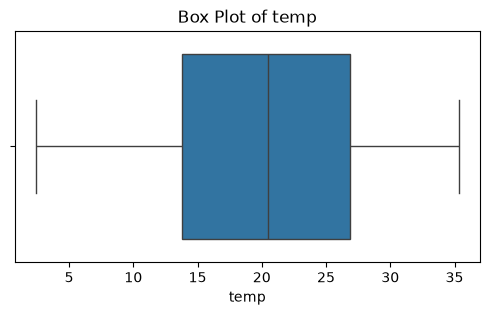

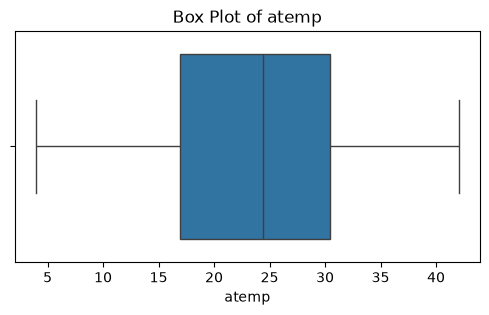

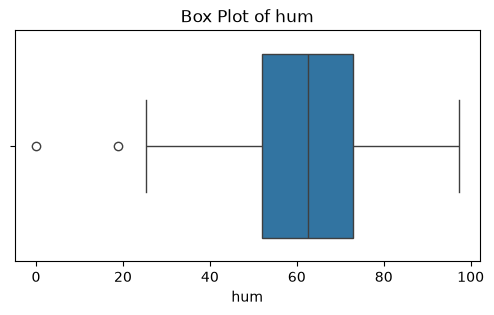

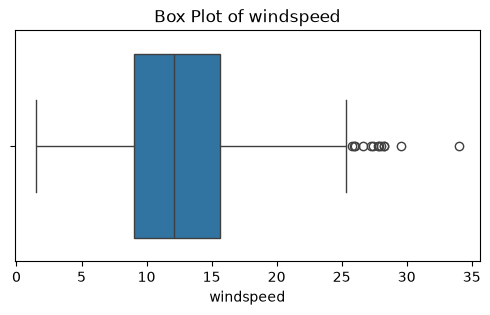

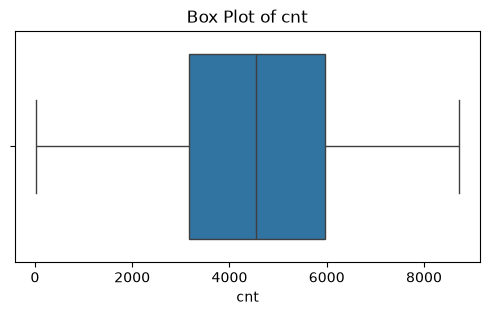

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']

for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

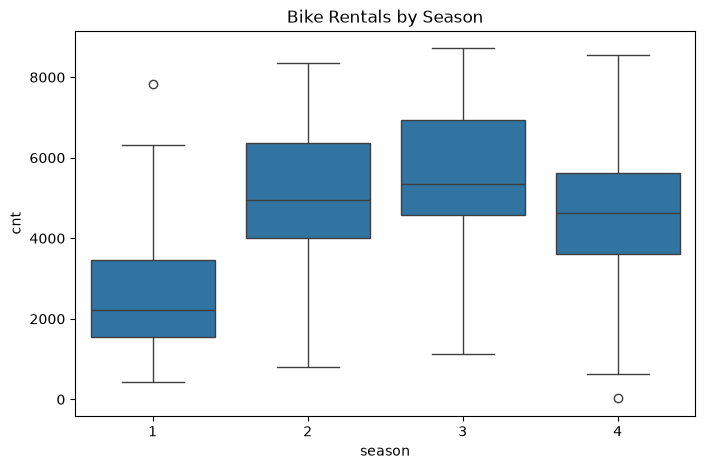

In [21]:
df_prev=pd.read_csv("C:/Users/acer/Desktop/machine_learning project/day.csv")
plt.figure(figsize=(8,5))
sns.boxplot(x='season', y='cnt', data=df_prev)
plt.title('Bike Rentals by Season')
plt.show()

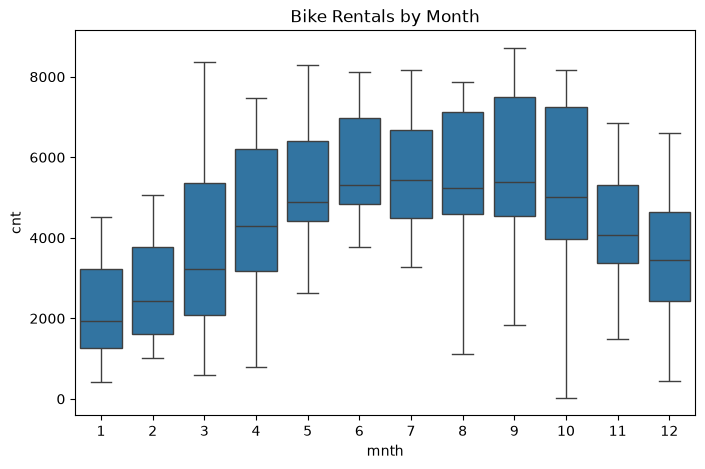

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='mnth', y='cnt', data=df_prev)
plt.title('Bike Rentals by Month')
plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler

numerical_features = ['temp', 'atemp', 'hum', 'windspeed']
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [26]:
X_test

,yr,holiday,workingday,temp,atemp,hum,windspeed,season_spring,season_summer,season_winter,...,mnth_oct,mnth_sep,weekday_mon,weekday_sat,weekday_sun,weekday_thu,weekday_tue,weekday_wed,weathersit_light snow/rain,weathersit_misty
468,1,0,0,-0.036858,0.045115,-0.927548,0.061038,0,1,0,...,0,0,0,1,0,0,0,0,0,0
148,0,0,0,0.909802,0.833767,1.293755,0.368750,0,1,0,...,0,0,0,0,1,0,0,0,0,0
302,0,0,0,-1.001808,-0.985369,-0.077711,-0.130104,0,0,1,...,1,0,0,0,1,0,0,0,0,0
355,0,0,1,-0.430158,-0.337451,0.862974,-1.858961,1,0,0,...,0,0,0,0,0,1,0,0,0,1
515,1,0,1,0.978401,0.931327,-0.997880,0.119343,0,1,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404,1,0,1,-1.299071,-1.352268,-0.511425,0.102742,1,0,0,...,0,0,0,0,0,1,0,0,0,0
390,1,0,1,-0.878331,-0.770693,0.947956,-1.509816,1,0,0,...,0,0,0,0,0,1,0,0,0,1
218,0,0,0,1.321393,1.450461,0.830741,0.202323,0,0,0,...,0,0,0,0,1,0,0,0,0,0
135,0,0,1,0.415893,0.431644,1.076902,-0.795037,0,1,0,...,0,0,1,0,0,0,0,0,0,0


**Linear Regression**

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model_lr=LinearRegression()
model_lr.fit(X_train,y_train)
y_pred=model_lr.predict(X_test)
model_lr.score(X_test,y_test)


0.862219721094228

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': [0.001, 0.01, 0.1, 'scale'],
    'epsilon': [0.01, 0.1, 0.5]
}

grid = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 1000, 'epsilon': 0.5, 'gamma': 0.1}
0.8814739915326758


In [34]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=1000, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print("R² Score:", model_rf.score(X_test, y_test))

R² Score: 0.9068020590917094


In [35]:
from sklearn.ensemble import GradientBoostingRegressor
model_gb = GradientBoostingRegressor(n_estimators=1000, random_state=42)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)
print("R² Score:", model_gb.score(X_test, y_test))

R² Score: 0.8832779716530123


In [38]:
model_modified_rf=GridSearchCV(
    RandomForestRegressor(random_state=42),
    {
        'n_estimators': [100, 500, 1000],
        'max_depth': [None, 10, 20,30,40,50],
        'min_samples_split': [2, 5, 10,20]
    },
    cv=5,
    scoring='r2',
    n_jobs=-1
)
model_modified_rf.fit(X_train, y_train)
print("R² Score:", model_modified_rf.score(X_test, y_test))
print(model_modified_rf.best_params_)
print(model_modified_rf.best_score_)

R² Score: 0.9021177577384366
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
0.8613929081691435


In [37]:
from xgboost import XGBRegressor


model_xgb=GridSearchCV(
    XGBRegressor(random_state=42),
    {
        'n_estimators': [100, 500, 1000],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    },
    cv=5,
    scoring='r2',
    n_jobs=-1
)
model_xgb.fit(X_train, y_train)
print("R² Score:", model_xgb.score(X_test, y_test))
print(model_xgb.best_params_)
print(model_xgb.best_score_)

R² Score: 0.8881784081459045
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
0.8754639983177185


In [39]:
import joblib
joblib.dump(model_modified_rf, 'bike_rental_model.pkl')
joblib.dump(scaler, 'price_scaler.pkl')

['price_scaler.pkl']